<a href="https://colab.research.google.com/github/D-Rockie/Deep-Learning-Lab-2026/blob/main/DLexp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 600

os.makedirs('figures', exist_ok=True)

def save_fig(fig, name):
    """Saves as vector EPS at 600 dpi (dpi only matters for any rasterized
    elements inside the EPS, e.g. scatter markers with alpha)."""
    path = f'figures/{name}.eps'
    fig.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved {path}")

In [ ]:
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv -O banknote.csv
print("Downloaded.")

--2026-07-14 06:42:55--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46400 (45K) [text/plain]
Saving to: ‘banknote.csv’

banknote.csv        100%[===================>]  45.31K  --.-KB/s    in 0.01s   

2026-07-14 06:42:55 (3.79 MB/s) - ‘banknote.csv’ saved [46400/46400]

Downloaded.


In [ ]:
df = pd.read_csv('banknote.csv', header=None,
                  names=['variance', 'skewness', 'curtosis', 'entropy', 'class'])
df.head() #first 5 rows

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.shape #number of rows and columns

(1372, 5)

In [ ]:
df.isnull().sum() #missing values

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [ ]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
df['class'].value_counts() #class count

,count
class,
0,762
1,610


Saved figures/01_histograms.eps


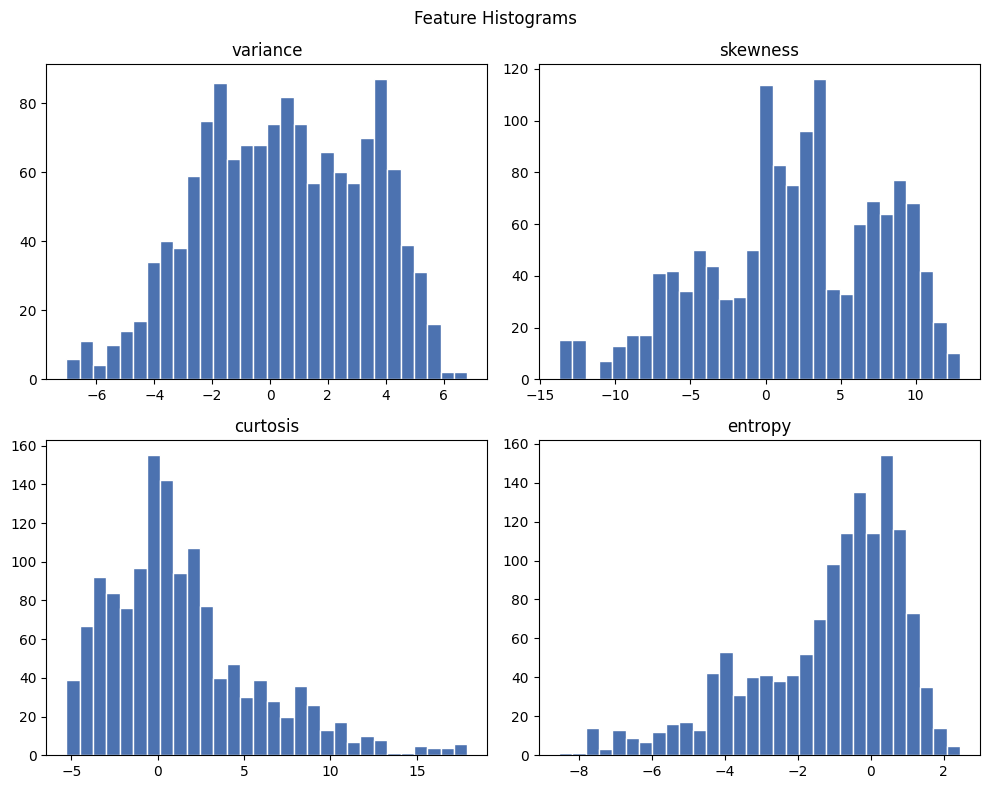

In [ ]:
features = ['variance', 'skewness', 'curtosis', 'entropy']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flat, features):
    ax.hist(df[feat], bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(feat)
fig.suptitle('Feature Histograms')
fig.tight_layout()
save_fig(fig, '01_histograms')
plt.show()

Saved figures/02_correlation_heatmap.eps


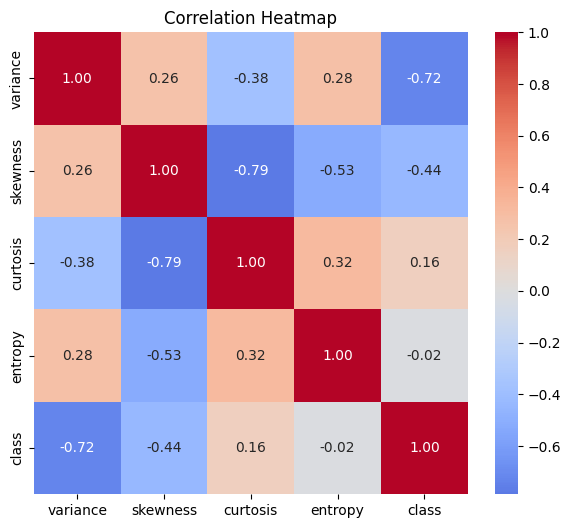

variance   -0.724843
skewness   -0.444688
entropy    -0.023424
curtosis    0.155883
class       1.000000
Name: class, dtype: float64


In [ ]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
save_fig(fig, '02_correlation_heatmap')
plt.show()

print(corr['class'].sort_values())

Most class-separating features: ['variance', 'skewness']


Saved figures/03_scatter.eps


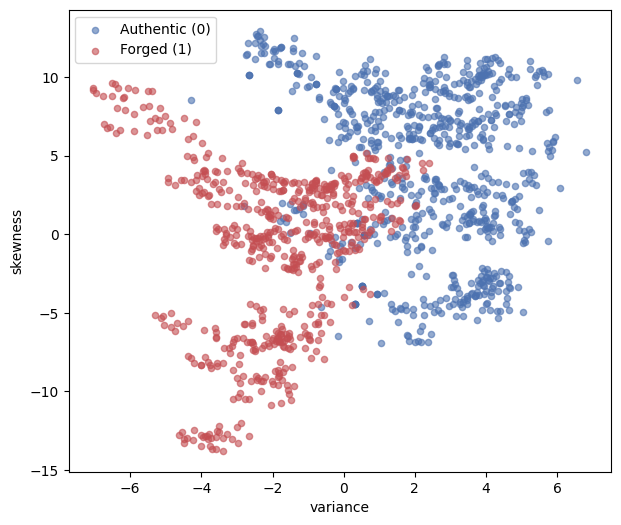

In [ ]:
class_corr = corr['class'].drop('class').abs().sort_values(ascending=False)
top2 = class_corr.index[:2].tolist()
print("Most class-separating features:", top2)

fig, ax = plt.subplots(figsize=(7, 6))
for cls, color, label in [(0, '#4C72B0', 'Authentic (0)'), (1, '#C44E52', 'Forged (1)')]:
    subset = df[df['class'] == cls]
    ax.scatter(subset[top2[0]], subset[top2[1]], c=color, label=label, alpha=0.6, s=20)
ax.set_xlabel(top2[0]); ax.set_ylabel(top2[1])
ax.legend()
save_fig(fig, '03_scatter')
plt.show()

Saved figures/04_boxplots.eps


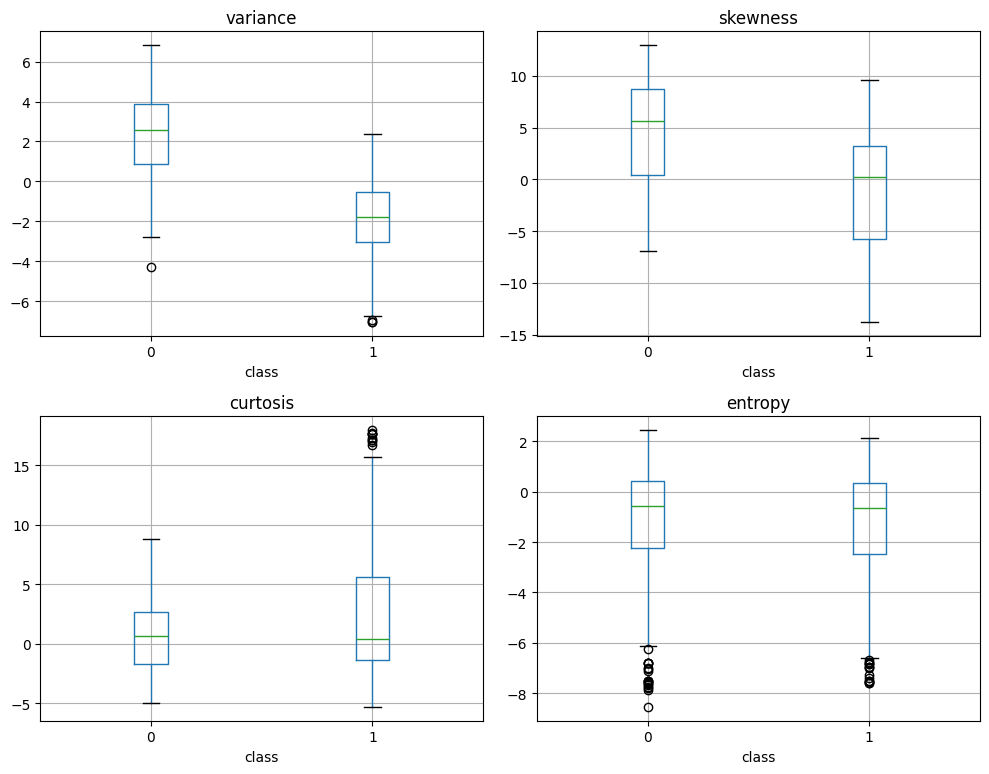

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flat, features):
    df.boxplot(column=feat, by='class', ax=ax)
    ax.set_title(feat)
fig.suptitle('Boxplots by Class')
plt.suptitle('')
fig.tight_layout()
save_fig(fig, '04_boxplots')
plt.show()

In [ ]:
X = df[features].values
y = df['class'].values

def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    """Stratified split — keeps class ratio the same in train and test."""
    rng = np.random.default_rng(random_state)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n_test = int(len(cls_idx) * test_size)
        test_idx.extend(cls_idx[:n_test])
        train_idx.extend(cls_idx[n_test:])
    train_idx, test_idx = np.array(train_idx), np.array(test_idx)
    rng.shuffle(train_idx); rng.shuffle(test_idx)
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train_raw, X_test_raw, y_train, y_test = train_test_split_manual(X, y)

# standardize using TRAIN stats only (never let test data leak into this)
mu, sigma = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.bincount(y_train))

Train: (1098, 4)  Test: (274, 4)
Train class balance: [610 488]


In [ ]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=100, random_state=42):
        rng = np.random.default_rng(random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = {'epoch': [], 'errors': [], 'weights': [], 'bias': []}

    def fit(self, X, y, verbose=False):
        n_samples = X.shape[0]
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for i in range(n_samples):
                xi, yi = X[i], y[i]
                z = xi @ self.w + self.b
                y_hat = 1 if z >= 0 else 0          # step activation
                if y_hat != yi:
                    misclassified += 1
                    error = yi - y_hat
                    self.w += self.lr * error * xi   # perceptron learning rule
                    self.b += self.lr * error

            self.history['epoch'].append(epoch)
            self.history['errors'].append(misclassified)
            self.history['weights'].append(self.w.copy())
            self.history['bias'].append(self.b)

            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Weights: {np.round(self.w,4)} | Bias: {self.b:.4f}")

            if misclassified == 0:
                if verbose: print(f"Converged at epoch {epoch}.")
                break
        return self

    def predict(self, X):
        z = X @ self.w + self.b
        return np.where(z >= 0, 1, 0)

In [ ]:
model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=100, random_state=42)
model.fit(X_train, y_train, verbose=True)

Epoch   1 | Misclassified:   59 | Weights: [-0.0576 -0.0786 -0.0676 -0.0298] | Bias: -0.0100
Epoch   2 | Misclassified:   39 | Weights: [-0.091  -0.1106 -0.0725 -0.0257] | Bias: -0.0400
Epoch   3 | Misclassified:   26 | Weights: [-0.1179 -0.1201 -0.0681 -0.0278] | Bias: -0.0400
Epoch   4 | Misclassified:   36 | Weights: [-0.1224 -0.1382 -0.0929 -0.0283] | Bias: -0.0400
Epoch   5 | Misclassified:   31 | Weights: [-0.131  -0.143  -0.1162 -0.0175] | Bias: -0.0500
Epoch   6 | Misclassified:   23 | Weights: [-0.1381 -0.1582 -0.112  -0.0218] | Bias: -0.0400
Epoch   7 | Misclassified:   21 | Weights: [-0.1458 -0.1524 -0.1138 -0.0146] | Bias: -0.0500
Epoch   8 | Misclassified:   24 | Weights: [-0.1489 -0.1662 -0.1115 -0.0384] | Bias: -0.0500
Epoch   9 | Misclassified:   22 | Weights: [-0.1377 -0.1788 -0.1271 -0.0309] | Bias: -0.0500
Epoch  10 | Misclassified:   17 | Weights: [-0.1432 -0.1653 -0.1407 -0.0272] | Bias: -0.0600
Epoch  11 | Misclassified:   20 | Weights: [-0.1478 -0.1692 -0.1445 -0

Saved figures/05_training_error.eps


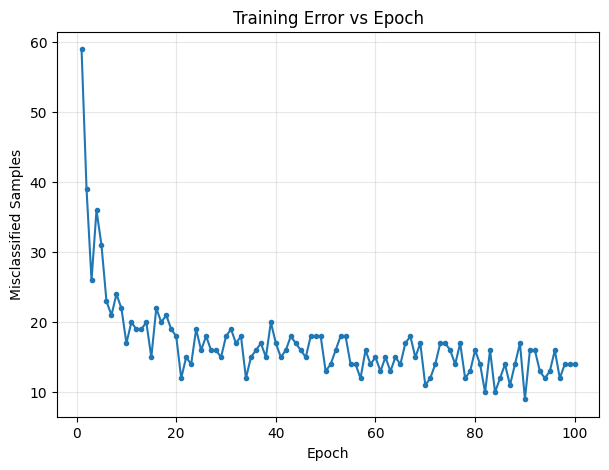

In [ ]:
hist = model.history
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(hist['epoch'], hist['errors'], marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Misclassified Samples')
ax.set_title('Training Error vs Epoch')
ax.grid(alpha=0.3)
save_fig(fig, '05_training_error')
plt.show()

Saved figures/06_weight_evolution.eps


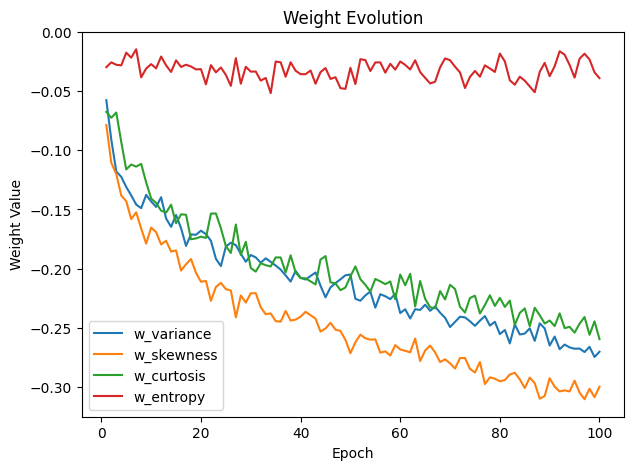

Saved figures/07_bias_evolution.eps


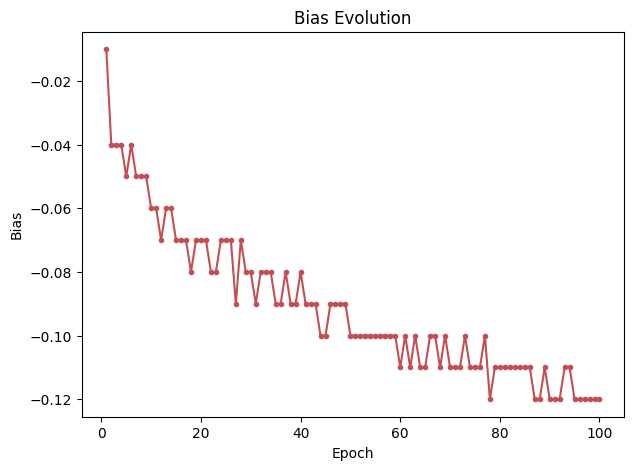

In [ ]:
weights_arr = np.array(hist['weights'])

fig, ax = plt.subplots(figsize=(7,5))
for i, lab in enumerate(features):
    ax.plot(hist['epoch'], weights_arr[:, i], label=f'w_{lab}')
ax.legend(); ax.set_xlabel('Epoch'); ax.set_ylabel('Weight Value')
ax.set_title('Weight Evolution')
save_fig(fig, '06_weight_evolution')
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(hist['epoch'], hist['bias'], color='#C44E52', marker='o', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Bias')
ax.set_title('Bias Evolution')
save_fig(fig, '07_bias_evolution')
plt.show()

In [ ]:
def classification_metrics(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    accuracy = (tp+tn) / (tp+tn+fp+fn)
    precision = tp / (tp+fp) if (tp+fp) > 0 else 0.0
    recall = tp / (tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    cm = np.array([[tn, fp], [fn, tp]])
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm}

y_pred = model.predict(X_test)
metrics = classification_metrics(y_test, y_pred)

print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-score:  {metrics['f1']:.4f}")
print(f"Confusion Matrix:\n{metrics['cm']}")

Accuracy:  0.9818
Precision: 0.9680
Recall:    0.9918
F1-score:  0.9798
Confusion Matrix:
[[148   4]
 [  1 121]]


Saved figures/08_confusion_matrix.eps


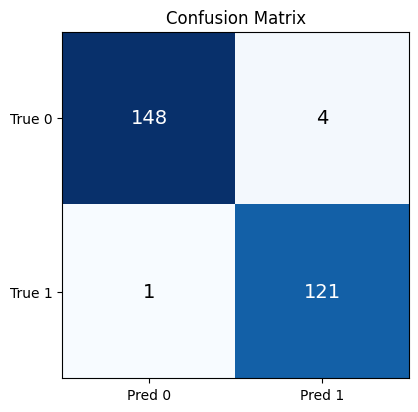

In [ ]:
cm = metrics['cm']
fig, ax = plt.subplots(figsize=(5,4.5))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred 0','Pred 1'])
ax.set_yticks([0,1]); ax.set_yticklabels(['True 0','True 1'])
ax.set_title('Confusion Matrix')
save_fig(fig, '08_confusion_matrix')
plt.show()

lr=0.001: final_train_errors=15, test_acc=0.9818
lr=0.01: final_train_errors=14, test_acc=0.9818


lr=0.1: final_train_errors=16, test_acc=0.9781
Saved figures/09_lr_comparison.eps


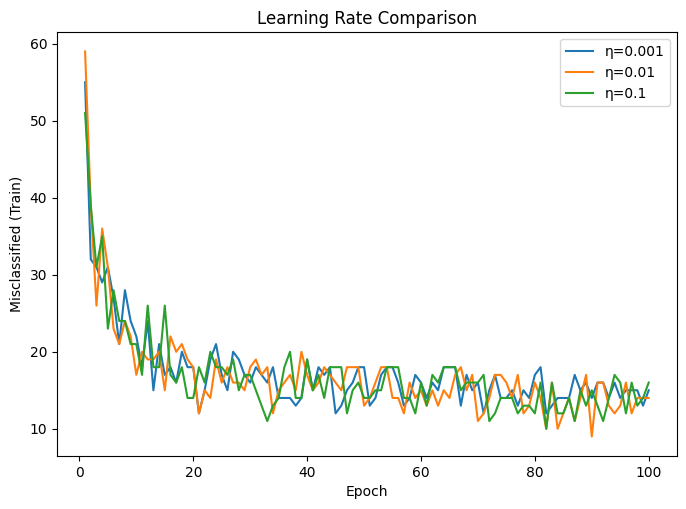

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
fig, ax = plt.subplots(figsize=(8, 5.5))

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=100, random_state=42)
    m.fit(X_train, y_train)
    y_pred_lr = m.predict(X_test)
    met = classification_metrics(y_test, y_pred_lr)
    ax.plot(m.history['epoch'], m.history['errors'], label=f'η={lr}')
    print(f"lr={lr}: final_train_errors={m.history['errors'][-1]}, test_acc={met['accuracy']:.4f}")

ax.set_xlabel('Epoch'); ax.set_ylabel('Misclassified (Train)')
ax.legend(); ax.set_title('Learning Rate Comparison')
save_fig(fig, '09_lr_comparison')
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron as SKPerceptron

sk = SKPerceptron(max_iter=100, eta0=0.01, random_state=42, tol=None)
sk.fit(X_train, y_train)
sk_pred = sk.predict(X_test)
sk_metrics = classification_metrics(y_test, sk_pred)

print("Ours:   ", {k: round(v,4) for k,v in metrics.items() if k!='cm'})
print("Sklearn:", {k: round(v,4) for k,v in sk_metrics.items() if k!='cm'})
print("\nOur weights:    ", np.round(model.w, 4), "bias:", round(model.b,4))
print("Sklearn weights:", np.round(sk.coef_[0], 4), "bias:", round(sk.intercept_[0],4))

Ours:    {'accuracy': np.float64(0.9818), 'precision': np.float64(0.968), 'recall': np.float64(0.9918), 'f1': np.float64(0.9798)}
Sklearn: {'accuracy': np.float64(0.9818), 'precision': np.float64(1.0), 'recall': np.float64(0.959), 'f1': np.float64(0.9791)}

Our weights:     [-0.2702 -0.2997 -0.2595 -0.0391] bias: -0.12
Sklearn weights: [-0.2445 -0.2735 -0.2758 -0.0046] bias: -0.13


2-feature accuracy: 0.8796 (vs 0.9818 with all 4 features)
Saved figures/10_decision_boundary.eps


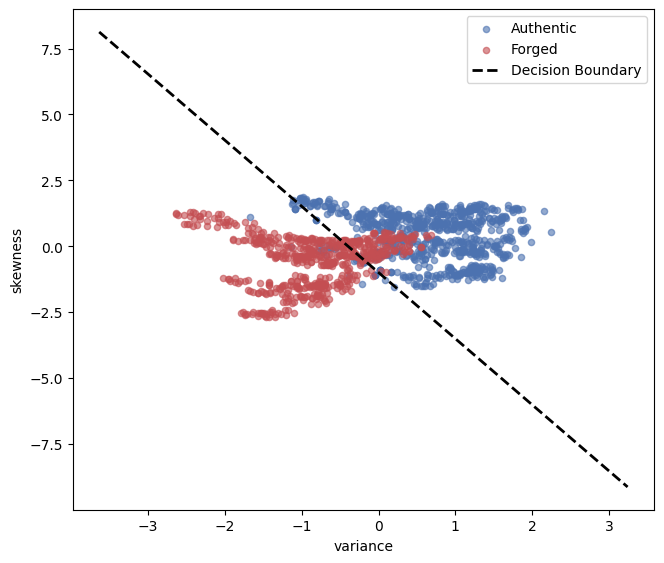

In [ ]:
idx = [features.index(f) for f in top2]
X_train_2d, X_test_2d = X_train[:, idx], X_test[:, idx]

model_2d = Perceptron(n_features=2, learning_rate=0.01, n_epochs=200, random_state=42)
model_2d.fit(X_train_2d, y_train)
acc_2d = classification_metrics(y_test, model_2d.predict(X_test_2d))['accuracy']
print(f"2-feature accuracy: {acc_2d:.4f} (vs {metrics['accuracy']:.4f} with all 4 features)")

X_all_2d = np.vstack([X_train_2d, X_test_2d])
y_all = np.concatenate([y_train, y_test])

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for cls, color, label in [(0, '#4C72B0', 'Authentic'), (1, '#C44E52', 'Forged')]:
    mask = y_all == cls
    ax.scatter(X_all_2d[mask,0], X_all_2d[mask,1], c=color, label=label, alpha=0.6, s=20)

w0, w1 = model_2d.w; b = model_2d.b
xs = np.linspace(X_all_2d[:,0].min()-1, X_all_2d[:,0].max()+1, 200)
ax.plot(xs, -(w0*xs + b)/w1, 'k--', linewidth=2, label='Decision Boundary')
ax.set_xlabel(top2[0]); ax.set_ylabel(top2[1]); ax.legend()
save_fig(fig, '10_decision_boundary')
plt.show()

In [ ]:
!zip -r figures.zip figures/
from google.colab import files
files.download('figures.zip')

  adding: figures/ (stored 0%)
  adding: figures/08_confusion_matrix.eps (deflated 99%)
  adding: figures/03_scatter.eps (deflated 63%)
  adding: figures/01_histograms.eps (deflated 82%)
  adding: figures/05_training_error.eps (deflated 68%)
  adding: figures/02_correlation_heatmap.eps (deflated 99%)
  adding: figures/10_decision_boundary.eps (deflated 65%)
  adding: figures/04_boxplots.eps (deflated 80%)
  adding: figures/09_lr_comparison.eps (deflated 69%)
  adding: figures/06_weight_evolution.eps (deflated 66%)
  adding: figures/07_bias_evolution.eps (deflated 68%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

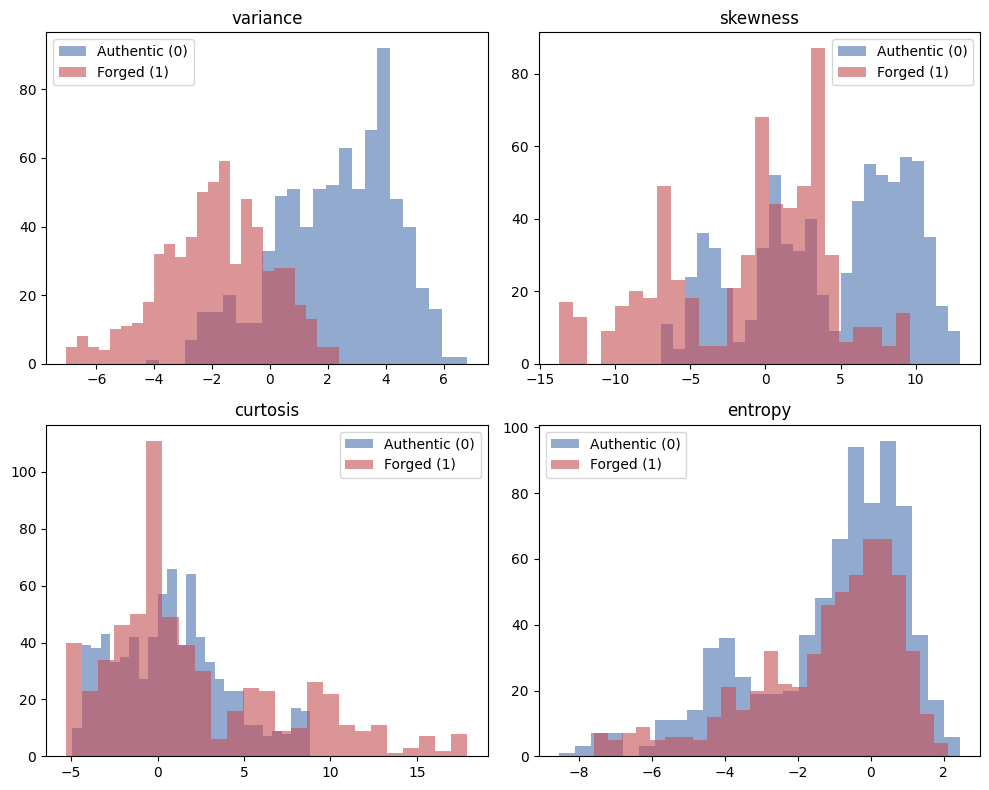

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flat, features):
    ax.hist(df[df['class']==0][feat], bins=25, alpha=0.6, label='Authentic (0)', color='#4C72B0')
    ax.hist(df[df['class']==1][feat], bins=25, alpha=0.6, label='Forged (1)', color='#C44E52')
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()